# Amazon Product Analysis, Sentiment Mining, and Recommendation System

## Project Objectives
This project analyzes Amazon product and review data to:
- explore pricing, discounts, ratings, and customer engagement
- perform sentiment analysis on customer reviews
- build a machine learning model for rating prediction
- create a simple content-based recommendation system

## Dataset Summary
The dataset contains product information, prices, discount percentages, ratings, review counts, product descriptions, and customer reviews. It supports work in EDA, NLP, recommendation systems, and pricing analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("C:/Users/Ruweida Ali/PYTHON/Amazon Sales Dataset/amazon.csv")
print(df.head())

   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessories|Accessories&Peripherals|...             ₹199   
3  Computers&Accessories|Accessories&Peripherals|...             ₹329   
4  Computers&Accessories|Accessories&Peripherals|...             ₹154   

  actual_price discount_percentage rating rating_count  \
0       ₹1,099                 64%    4.2       24,269   
1         ₹349                 43%  

In [5]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n")
print(df.dtypes)

Shape: (1465, 16)

Columns:
 ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']

Data types:

product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object


In [6]:
df.isnull().sum().sort_values(ascending=False)

rating_count           2
product_id             0
category               0
product_name           0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [ ]:
# Remove ₹ and commas
df['discounted_price'] = df['discounted_price'].str.replace('₹', '').str.replace(',', '')
df['actual_price'] = df['actual_price'].str.replace('₹', '').str.replace(',', '')

# Remove %
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '')

# Remove commas from rating_count
df['rating_count'] = df['rating_count'].str.replace(',', '')

# Convert to numeric
df['discounted_price'] = pd.to_numeric(df['discounted_price'], errors='coerce')
df['actual_price'] = pd.to_numeric(df['actual_price'], errors='coerce')
df['discount_percentage'] = pd.to_numeric(df['discount_percentage'], errors='coerce')
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')


AttributeError: Can only use .str accessor with string values!

In [12]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [13]:
df.dtypes

product_id              object
product_name            object
category                object
discounted_price       float64
actual_price           float64
discount_percentage      int64
rating                 float64
rating_count           float64
about_product           object
user_id                 object
user_name               object
review_id               object
review_title            object
review_content          object
img_link                object
product_link            object
dtype: object

In [14]:
df[['discounted_price', 'actual_price', 'discount_percentage', 'rating_count','rating']].head()

,discounted_price,actual_price,discount_percentage,rating_count,rating
0,399.0,1099.0,64,24269.0,4.2
1,199.0,349.0,43,43994.0,4.0
2,199.0,1899.0,90,7928.0,3.9
3,329.0,699.0,53,94363.0,4.2
4,154.0,399.0,61,16905.0,4.2


In [15]:
df.isnull().sum().sort_values(ascending=False)

rating_count           2
rating                 1
product_id             0
product_name           0
discounted_price       0
category               0
discount_percentage    0
actual_price           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [16]:
df['rating_count'] = df['rating_count'].fillna(df['rating_count'].median())

In [17]:
df.isnull().sum().sort_values(ascending=False)

rating                 1
product_id             0
category               0
product_name           0
discounted_price       0
actual_price           0
discount_percentage    0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [18]:
df['rating'] = df['rating'].fillna(df['rating'].median())

In [19]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df["discount_amount"] = df["actual_price"] - df["discounted_price"]

df["review_length"] = df["review_content"].astype(str).apply(len)
df["title_length"] = df["review_title"].astype(str).apply(len)
df["product_name_length"] = df["product_name"].astype(str).apply(len)

df["price_gap_ratio"] = df["discount_amount"] / df["actual_price"]
df["price_gap_ratio"] = df["price_gap_ratio"].replace([np.inf, -np.inf], np.nan)

df["engagement_score"] = df["rating_count"] * df["rating"]

df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,...,review_title,review_content,img_link,product_link,discount_amount,review_length,title_length,product_name_length,price_gap_ratio,engagement_score
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...",...,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,700.0,483,124,162,0.636943,101929.8
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...",...,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,150.0,1186,181,193,0.429799,175976.0
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...",...,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,1700.0,271,137,136,0.895208,30919.2
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...",...,"Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,370.0,443,140,199,0.529328,396324.6
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...",...,"As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,245.0,2451,138,110,0.614035,71001.0


In [22]:
df[[
    "discounted_price", "actual_price", "discount_percentage",
    "rating", "rating_count", "discount_amount",
    "review_length", "engagement_score"
]].describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count,discount_amount,review_length,engagement_score
count,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1.465000e+03
mean,3125.310874,5444.990635,47.691468,4.096587,18277.634812,2319.679761,1394.137884,7.613989e+04
std,6944.304394,10874.826864,21.635905,0.291574,42727.398216,4604.473790,1823.491796,1.800456e+05
min,39.000000,39.000000,0.000000,2.000000,2.000000,0.000000,67.000000,4.000000e+00
25%,325.000000,800.000000,32.000000,4.000000,1191.000000,371.000000,505.000000,4.760100e+03
50%,799.000000,1650.000000,50.000000,4.100000,5179.000000,800.000000,823.000000,2.152000e+04
75%,1999.000000,4295.000000,63.000000,4.300000,17325.000000,1953.000000,1388.000000,7.103250e+04
max,77990.000000,139900.000000,94.000000,5.000000,426973.000000,61910.000000,18547.000000,1.878681e+06


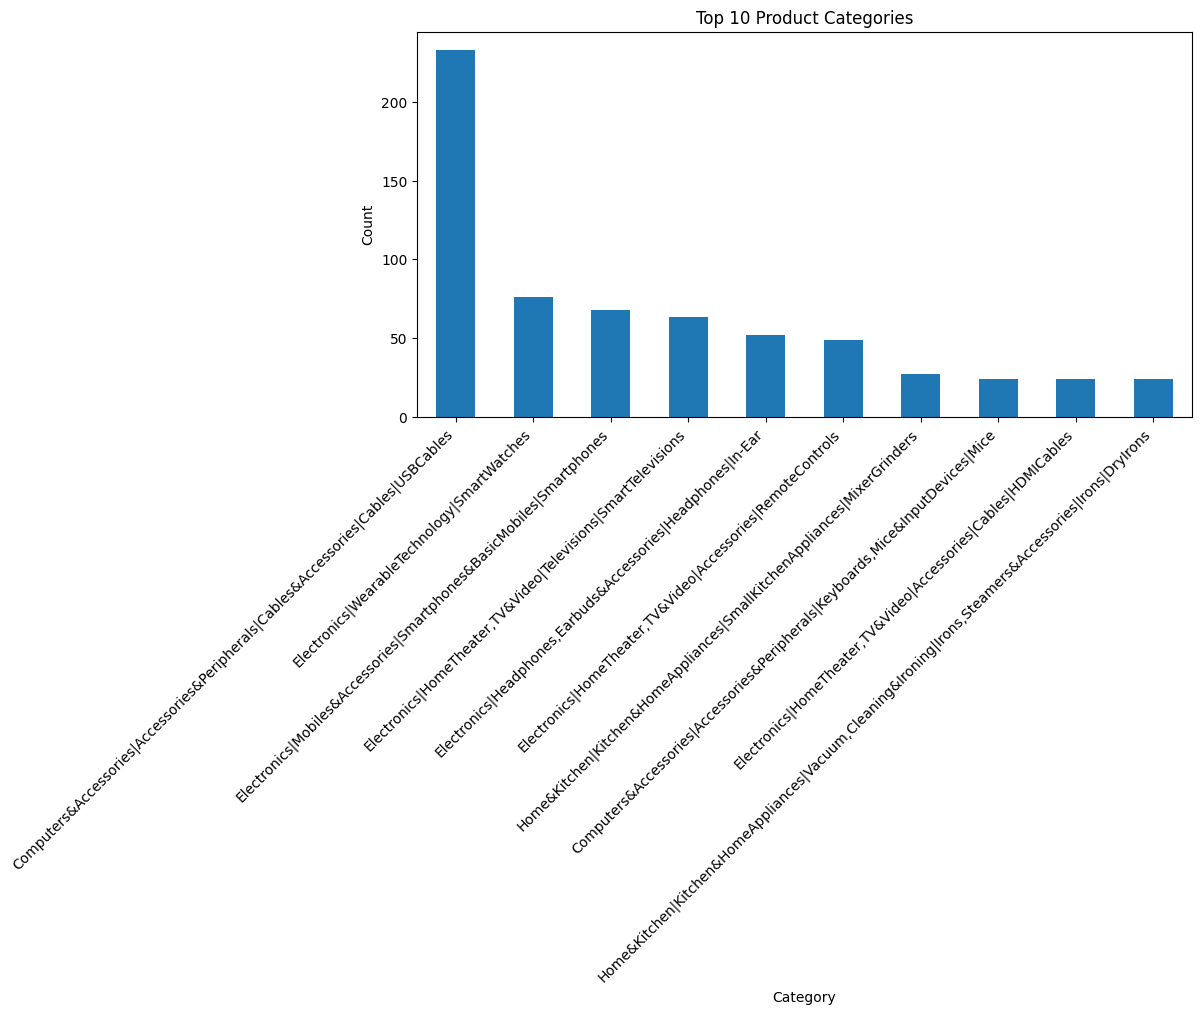

In [23]:
#Top product categorie
top_categories = df["category"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_categories.plot(kind="bar")
plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

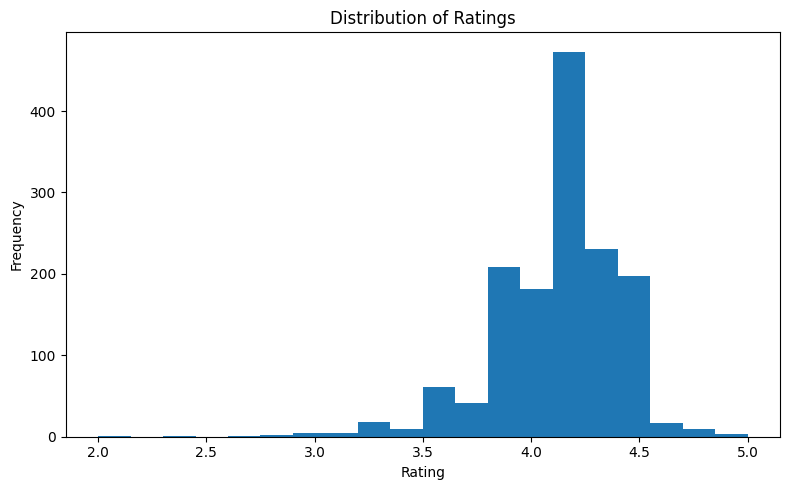

In [24]:
#Rating distribution
plt.figure(figsize=(8,5))
df["rating"].plot(kind="hist", bins=20)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

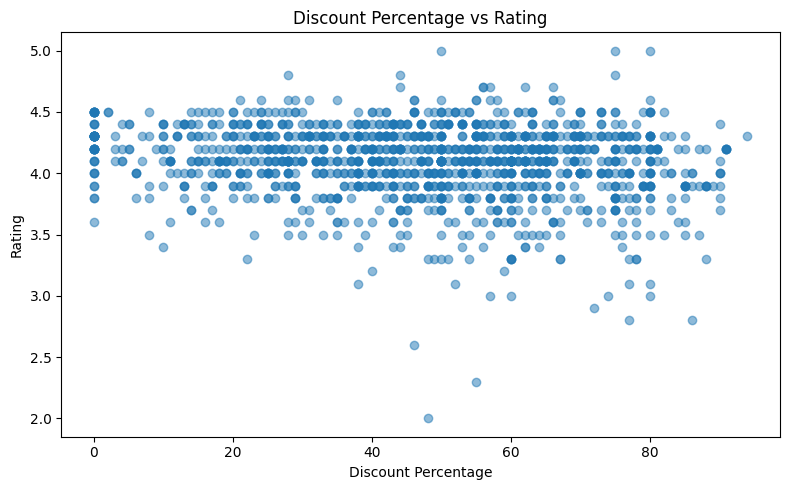

In [25]:
#Discount percentage vs rating
plt.figure(figsize=(8,5))
plt.scatter(df["discount_percentage"], df["rating"], alpha=0.5)
plt.title("Discount Percentage vs Rating")
plt.xlabel("Discount Percentage")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

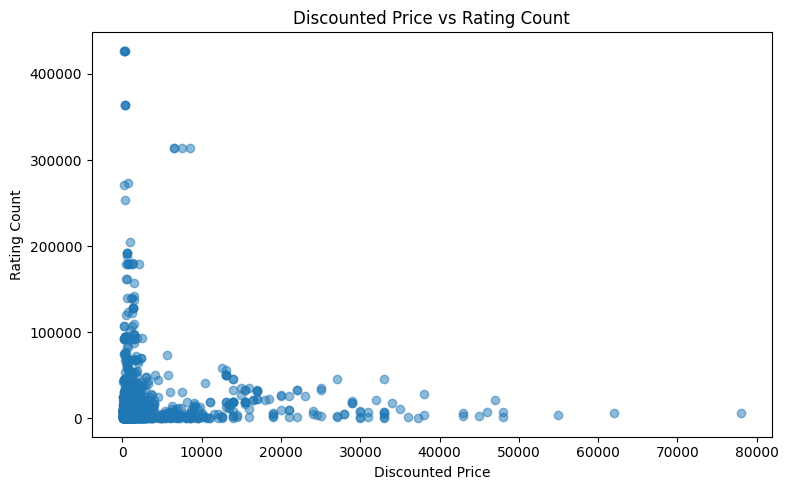

In [26]:
#Discounted price vs rating count
plt.figure(figsize=(8,5))
plt.scatter(df["discounted_price"], df["rating_count"], alpha=0.5)
plt.title("Discounted Price vs Rating Count")
plt.xlabel("Discounted Price")
plt.ylabel("Rating Count")
plt.tight_layout()
plt.show()

In [27]:
#correlation analysis
numeric_cols = [
    "discounted_price", "actual_price", "discount_percentage",
    "rating", "rating_count", "discount_amount",
    "review_length", "engagement_score", "price_gap_ratio"
]

corr = df[numeric_cols].corr()
corr

,discounted_price,actual_price,discount_percentage,rating,rating_count,discount_amount,review_length,engagement_score,price_gap_ratio
discounted_price,1.000000,0.961915,-0.242412,0.120335,-0.027081,0.763683,0.309129,-0.026816,-0.242008
actual_price,0.961915,1.000000,-0.118098,0.121636,-0.035959,0.911069,0.296003,-0.035704,-0.117705
discount_percentage,-0.242412,-0.118098,1.000000,-0.155273,0.011097,0.086675,-0.125652,0.010494,0.999926
rating,0.120335,0.121636,-0.155273,1.000000,0.101526,0.105795,0.077353,0.114536,-0.155337
rating_count,-0.027081,-0.035959,0.011097,0.101526,1.000000,-0.044087,0.154628,0.999061,0.010516
discount_amount,0.763683,0.911069,0.086675,0.105795,-0.044087,1.000000,0.232882,-0.043882,0.086993
review_length,0.309129,0.296003,-0.125652,0.077353,0.154628,0.232882,1.000000,0.150787,-0.125506
engagement_score,-0.026816,-0.035704,0.010494,0.114536,0.999061,-0.043882,0.150787,1.000000,0.009908
price_gap_ratio,-0.242008,-0.117705,0.999926,-0.155337,0.010516,0.086993,-0.125506,0.009908,1.000000


In [28]:
corr["rating"].sort_values(ascending=False)

rating                 1.000000
actual_price           0.121636
discounted_price       0.120335
engagement_score       0.114536
discount_amount        0.105795
rating_count           0.101526
review_length          0.077353
discount_percentage   -0.155273
price_gap_ratio       -0.155337
Name: rating, dtype: float64

In [29]:
from textblob import TextBlob

In [31]:
#Creating a sentiment score for review content
df["sentiment_score"] = df["review_content"].astype(str).apply(
    lambda x: TextBlob(x).sentiment.polarity
)

In [32]:
#creating sentiment label
def get_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_label"] = df["sentiment_score"].apply(get_sentiment)

In [33]:
df[["review_content", "sentiment_score", "sentiment_label"]].head()

,review_content,sentiment_score,sentiment_label
0,Looks durable Charging is fine tooNo complains...,0.481944,Positive
1,I ordered this cable to connect my phone to An...,0.274318,Positive
2,"Not quite durable and sturdy,https://m.media-a...",0.600000,Positive
3,"Good product,long wire,Charges good,Nice,I bou...",0.240370,Positive
4,"Bought this instead of original apple, does th...",0.262740,Positive


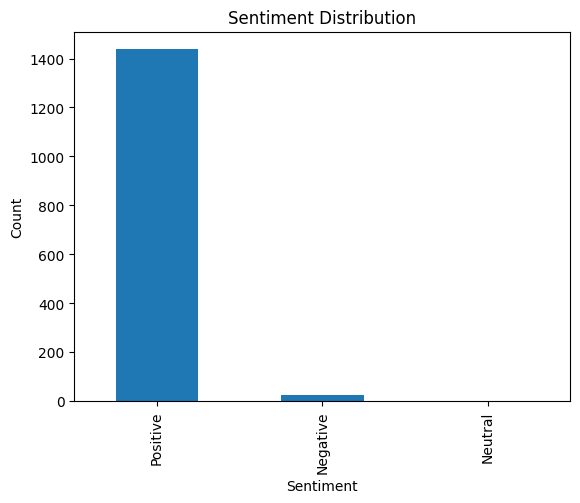

In [34]:
df["sentiment_label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [35]:
df.groupby("sentiment_label")["rating"].mean()

sentiment_label
Negative    3.919231
Neutral     4.200000
Positive    4.099722
Name: rating, dtype: float64

In [36]:
df.groupby("sentiment_label")["engagement_score"].mean()

sentiment_label
Negative    24657.526923
Neutral      1759.800000
Positive    77122.450974
Name: engagement_score, dtype: float64

In [37]:
#ML MODEL 
features = df[[
    "discounted_price",
    "actual_price",
    "discount_percentage",
    "rating_count",
    "discount_amount",
    "review_length",
    "title_length",
    "product_name_length",
    "price_gap_ratio",
    "sentiment_score"
]]

target = df["rating"]

In [38]:
features = features.dropna()
target = target.loc[features.index]

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

In [40]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [41]:
y_pred = model.predict(X_test)

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.18526289784637576
MSE: 0.07217424714372549
RMSE: 0.2686526514734695
R2 Score: 0.11611751320360275


In [43]:
#Model is weak-trying to convert category to number
df = pd.get_dummies(df, columns=['category'], drop_first=True)

In [44]:
features = df.drop(columns=[
    'rating',
    'product_id',
    'product_name',
    'about_product',
    'user_id',
    'user_name',
    'review_id',
    'review_title',
    'review_content',
    'img_link',
    'product_link'
])

In [45]:
#Remove the weak features
features = features.drop(columns=[
    'review_length',
    'title_length',
    'product_name_length'
], errors='ignore')

In [46]:
#Scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

ValueError: could not convert string to float: 'Positive'

In [47]:
# Keep only numeric columns
features = df.drop(columns=['rating'], errors='ignore')
features = features.select_dtypes(include=['number'])

# Remove rows with missing values just in case
features = features.dropna()
target = df.loc[features.index, 'rating']

# Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, target, test_size=0.2, random_state=42
)

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, df['rating'], test_size=0.2, random_state=42
)

In [49]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [50]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))

R2: 0.17045499552844656


In [51]:
#Recommendation system
df["combined_text"] = (
    df["product_name"].astype(str) + " " +
    df["category"].astype(str) + " " +
    df["about_product"].astype(str)
)

KeyError: 'category'

In [52]:
df["combined_text"] = (
    df["product_name"].astype(str) + " " +
    df["about_product"].astype(str)
)

In [53]:
#Recommendation system
df["combined_text"] = (
    df["product_name"].astype(str) + " " +
    df["category"].astype(str) + " " +
    df["about_product"].astype(str)
)

KeyError: 'category'

In [54]:
df_original["combined_text"] = (
    df_original["product_name"].astype(str) + " " +
    df_original["category"].astype(str) + " " +
    df_original["about_product"].astype(str)
)

NameError: name 'df_original' is not defined

In [55]:
df["combined_text"] = (
    df["product_name"].astype(str) + " " +
    df["about_product"].astype(str)
)

In [56]:
#convert text to numbers TFIDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = tfidf.fit_transform(df["combined_text"])

In [57]:
#CALCULATE SIMILARITY
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [58]:
#Create recommended function
def recommend_products(product_name, df, cosine_sim, top_n=5):
    product_name = product_name.lower()
    
    matches = df[df["product_name"].str.lower().str.contains(product_name, na=False)]
    
    if matches.empty:
        return "Product not found."
    
    idx = matches.index[0]
    
    similarity_scores = list(enumerate(cosine_sim[idx]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    
    similar_indices = [i[0] for i in similarity_scores[1:top_n+1]]
    
    return df.iloc[similar_indices][[
        "product_name", "rating", "discounted_price"
    ]]

In [59]:
recommend_products("boAt", df, cosine_sim)

,product_name,rating,discounted_price
392,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,4.2,329.0
628,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,4.2,329.0
92,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,4.2,299.0
113,"boAt Type C A750 Stress Resistant, Tangle-free...",4.1,399.0
74,"boAt Type C A750 Stress Resistant, Tangle-free...",4.1,399.0


In [ ]:
#To avoid repeated recommendations, you can remove duplicates from the returned results:
def recommend_products(product_name, df, cosine_sim, top_n=5):
    product_name = product_name.lower()
    
    matches = df[df["product_name"].str.lower().str.contains(product_name, na=False)]
    
    if matches.empty:
        return "Product not found."
    
    idx = matches.index[0]
    
    similarity_scores = list(enumerate(cosine_sim[idx]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    
    similar_indices = [i[0] for i in similarity_scores[1:top_n+10]]
    
    recommendations = df.iloc[similar_indices][[
        "product_name", "rating", "discounted_price"
    ]].drop_duplicates(subset=["product_name"]).head(top_n)
    
    return recommendations

In [61]:
recommend_products("boAt", df, cosine_sim)

,product_name,rating,discounted_price
392,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,4.2,329.00
92,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,4.2,299.00
113,"boAt Type C A750 Stress Resistant, Tangle-free...",4.1,399.00
74,"boAt Type C A750 Stress Resistant, Tangle-free...",4.1,399.00
6,"boAt Micro USB 55 Tangle-free, Sturdy Micro US...",4.1,176.63
